In [23]:
import os
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Obtener información desde el CSV de Training_set.csv

El dataset contiene un CSV llamado Training_set.csv donde viene el nombre del archivo junto con la clasificación de la mariposa. Se utilizarán estos datos para entrenar al modelo.

In [24]:
data_csv = pd.read_csv("Training_set.csv")

data_csv.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [25]:
from sklearn.model_selection import train_test_split

# Separar el archivo CSV del dataset en 70% entrenamiento y 30% testing
train_csv, test_csv = train_test_split(data_csv, test_size=0.3, random_state=54, stratify=data_csv['label'])

len(train_csv)


4549

In [26]:

len(test_csv)

1950

In [27]:
CLASSES_PER_PLOT = 15

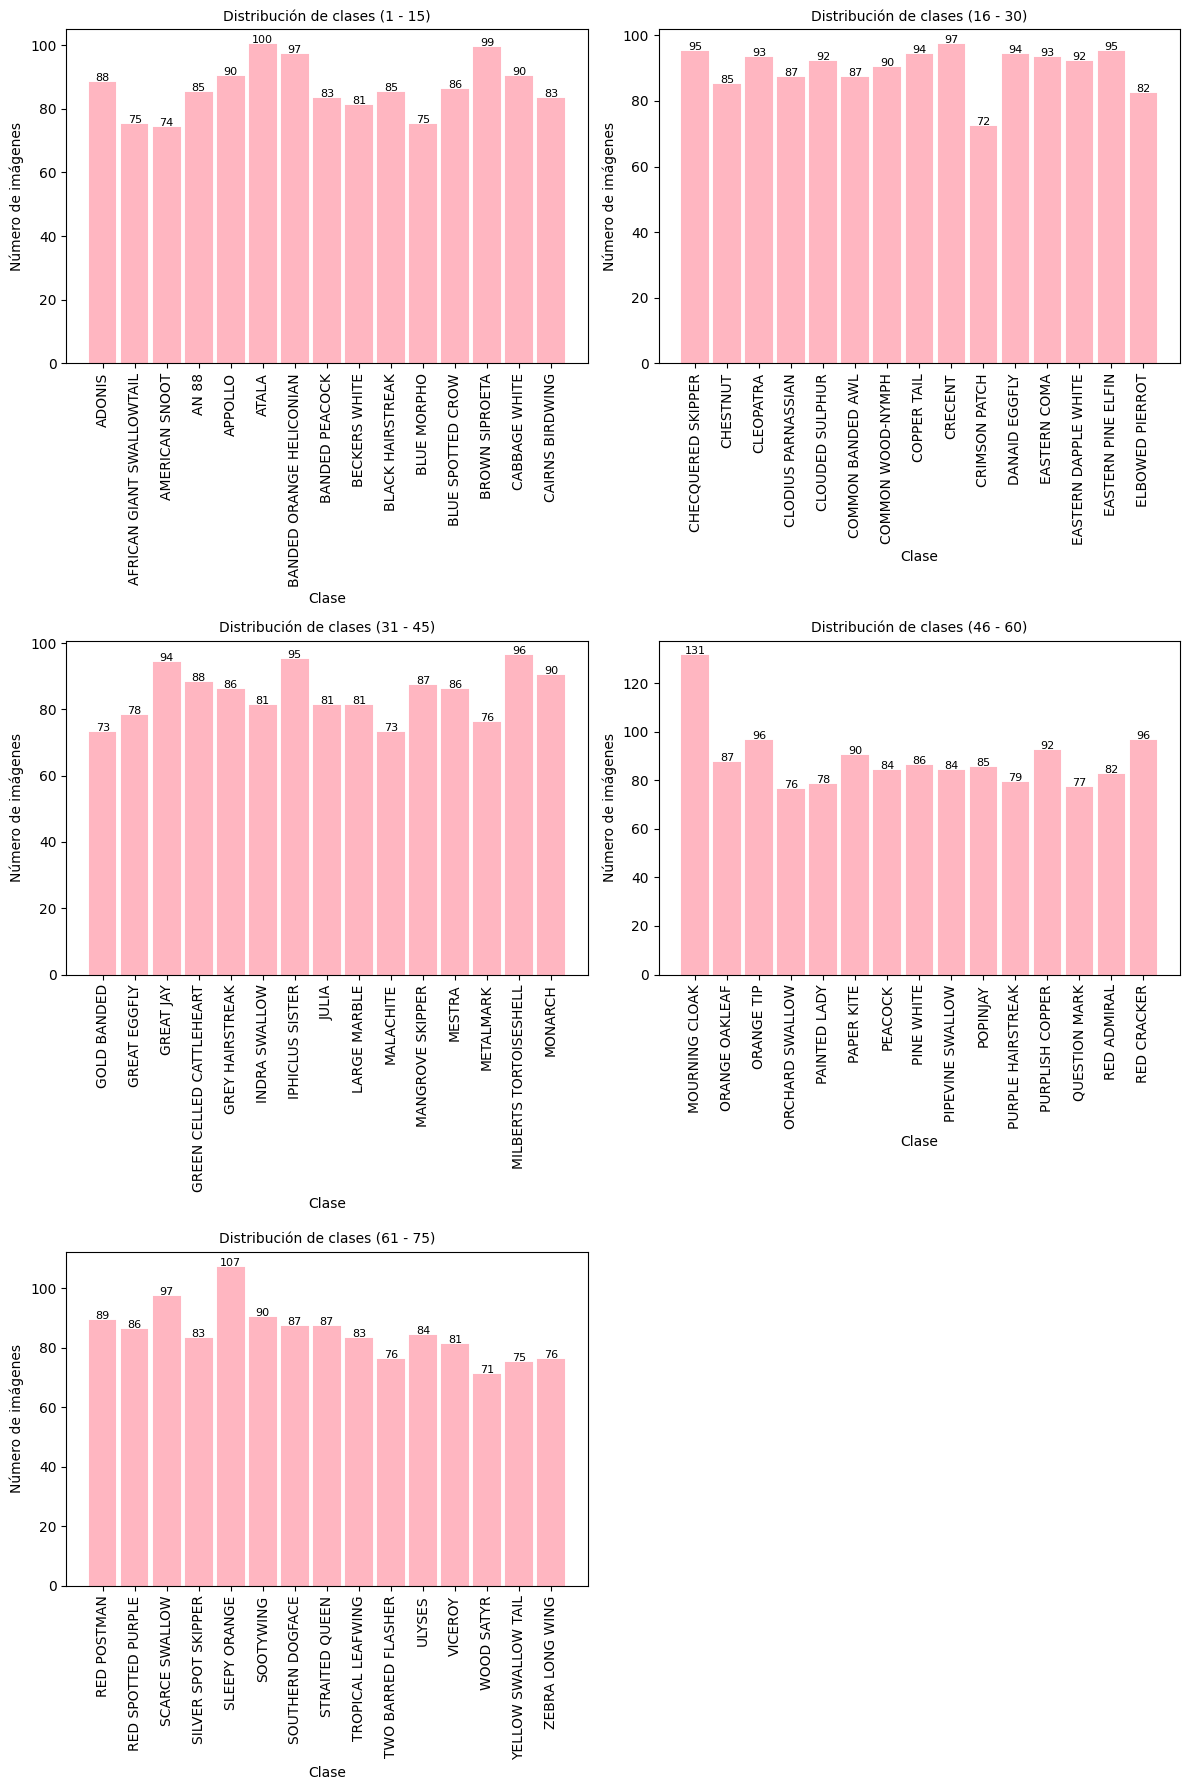

In [28]:
class_counts = data_csv['label'].value_counts().sort_index()


fig, axes = plt.subplots(3, 2, figsize=(12, 18))
axes = axes.flatten()

for plot_idx, start in enumerate(range(0, len(class_counts), CLASSES_PER_PLOT)):
    subset = class_counts.iloc[start:start+CLASSES_PER_PLOT]

    ax = axes[plot_idx]
    
    bars = ax.bar(
        subset.index,
        subset.values,
        color='lightpink',
        edgecolor='lightpink',
        linewidth=1.5
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    ax.set_title(
        f'Distribución de clases ({start+1} - {start+len(subset)})',
        fontsize=10,
        fontweight='light'
    )

    ax.set_xlabel('Clase')
    ax.set_ylabel('Número de imágenes')
    
    ax.tick_params(axis='x', rotation=90)



axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [29]:
train_csv["filepath"] = train_csv["filename"].apply(

    lambda x: os.path.join("train", x)

)

train_csv

,filename,label,filepath
47,Image_48.jpg,BANDED PEACOCK,train/Image_48.jpg
100,Image_101.jpg,BECKERS WHITE,train/Image_101.jpg
1758,Image_1759.jpg,LARGE MARBLE,train/Image_1759.jpg
5647,Image_5648.jpg,CLOUDED SULPHUR,train/Image_5648.jpg
5602,Image_5603.jpg,ZEBRA LONG WING,train/Image_5603.jpg
...,...,...,...
4988,Image_4989.jpg,GREAT JAY,train/Image_4989.jpg
2383,Image_2384.jpg,BANDED ORANGE HELICONIAN,train/Image_2384.jpg
4705,Image_4706.jpg,CLODIUS PARNASSIAN,train/Image_4706.jpg
3046,Image_3047.jpg,CLODIUS PARNASSIAN,train/Image_3047.jpg


In [30]:
test_csv["filepath"] = test_csv["filename"].apply(
    lambda x: os.path.join("train", x)
)
test_csv.head()

,filename,label,filepath
806,Image_807.jpg,CRIMSON PATCH,train/Image_807.jpg
446,Image_447.jpg,SOOTYWING,train/Image_447.jpg
1628,Image_1629.jpg,COPPER TAIL,train/Image_1629.jpg
3721,Image_3722.jpg,CLODIUS PARNASSIAN,train/Image_3722.jpg
3148,Image_3149.jpg,GREAT JAY,train/Image_3149.jpg


### Llevar a cabo la augmentation
En esta sección, se lleva a cabo la aumentación de datos. Se utiliza el comando ImageDataGenerator importado de tensorflow, y se generan las imágenes nuevas a partir del mismo.

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Se generan las imágenes con los parámetros de modificación especificados
train_datagen = ImageDataGenerator(
    rescale = 1./255, # convierte los valores de los pixeles a un número entre 0-1
    rotation_range = 10, # rango de grados para rotar la imagen
    width_shift_range = 0.2, # rango de porcentaje para incrementar el ancho
    height_shift_range = 0.2, # rango de porcentaje para incrementar la altura
    shear_range = 0.3, # rango de % aplicar transformaciones de deformación
    zoom_range = 0.3, # rango de % para aplicar transformaciones de zoom
    horizontal_flip = True,
    validation_split = 0.2 # Allocate 20% of the training data for validation
)

In [32]:
IMG_SIZE = (299, 299)

In [33]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe = train_csv,
    x_col="filepath", # path del archivo
    y_col="label",
    target_size = IMG_SIZE,
    batch_size = 8,
    class_mode='categorical', # ya que son múltiples categorías
    subset='training'
  )

images, labels = train_generator[0]

# Se obtiene el objeto de los índicies de las clases
# a partir de lo que se generó en train_generator
class_indices = train_generator.class_indices

# DataFrame para visualizar las clases posibles
class_indices_df = pd.DataFrame.from_dict(class_indices, orient='index', columns=['Number'])

class_indices_df



Found 3640 validated image filenames belonging to 75 classes.


,Number
ADONIS,0
AFRICAN GIANT SWALLOWTAIL,1
AMERICAN SNOOT,2
AN 88,3
APPOLLO,4
...,...
ULYSES,70
VICEROY,71
WOOD SATYR,72
YELLOW SWALLOW TAIL,73


In [34]:
val_generator = train_datagen.flow_from_dataframe(
    dataframe=train_csv,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=8,
    class_mode='categorical',
    subset='validation'
)

Found 909 validated image filenames belonging to 75 classes.


In [35]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_csv,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size = 8,
    class_mode='categorical',
    shuffle=False
)

print(f"Number of test images: {test_generator.samples}")

Found 1950 validated image filenames belonging to 75 classes.
Number of test images: 1950


### Visualización
Se imprimen las imágenes generadas para la aumentación junto con el tipo de mariposa que son.

<Figure size 640x480 with 0 Axes>

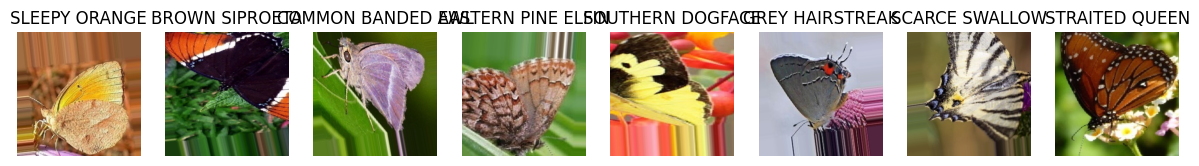

<Figure size 640x480 with 0 Axes>

In [36]:
# Se voltea el orden del diccionario class_indices para que sea
# índice: valor en lugar de valor: índice
idx_to_class = {v: k for k, v in class_indices.items()}

f, axarr = plt.subplots(1, images.shape[0], figsize=(15, 4))

for i in range(images.shape[0]):
  axarr[i].imshow(images[i])
  class_index = labels[i].argmax()
  class_name = idx_to_class[class_index]
  axarr[i].set_title(class_name) # configurar el nombr de la clase de mariposa
  axarr[i].axis("off")

plt.figure()

### CNN para el modelo de análisis

In [37]:
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

In [38]:
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

base_model.trainable = False

num_classes = len(class_indices)

model = models.Sequential()

model.add(base_model)

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(num_classes, activation='softmax'))

model.summary()

model.compile(loss='categorical_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['acc'])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 75)             │        19,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,346,603 (85.25 MB)

 Trainable params: 543,819 (2.07 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

### Entrenamiento del modelo
Se ejecuta el entrenamiento del modelo (en este caso únicamente en una época) y se grafica utilizando matplotlib para generar dos gráficos; uno que muestre la evolución del valor de accuracy y otro que muestra la evolución de loss.

Cuando existen más épocas hay mayor cantidad de puntos que muestran cómo evoluciona el entrenamiento del modelo; si sube el loss o baja, si el accuracy incrementa, etc.

In [39]:
checkpoint_filepath = 'checkpoints/butterfly_model_new.keras'

# print(f"Model loaded successfully from: {checkpoint_filepath}")
#loaded_model.summary()

In [40]:
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_acc',
    mode='max',
    save_best_only=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_acc',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1)

In [41]:
import os

os.path.exists(checkpoint_filepath)

True

In [44]:
loaded_model = tf.keras.models.load_model(checkpoint_filepath)

In [43]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[model_checkpoint, reduce_lr]
)

Epoch 1/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 229s 498ms/step - acc: 0.0860 - loss: 4.0660 - val_acc: 0.1870 - val_loss: 3.6336 - learning_rate: 1.0000e-04
Epoch 2/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 235s 516ms/step - acc: 0.1670 - loss: 3.4783 - val_acc: 0.3080 - val_loss: 3.0287 - learning_rate: 1.0000e-04
Epoch 3/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 240s 527ms/step - acc: 0.2522 - loss: 3.0011 - val_acc: 0.3795 - val_loss: 2.5916 - learning_rate: 1.0000e-04
Epoch 4/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 238s 523ms/step - acc: 0.3060 - loss: 2.6859 - val_acc: 0.4587 - val_loss: 2.3056 - learning_rate: 1.0000e-04
Epoch 5/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 236s 519ms/step - acc: 0.3547 - loss: 2.4446 - val_acc: 0.5149 - val_loss: 2.0789 - learning_rate: 1.0000e-04
Epoch 6/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 241s 530ms/step - acc: 0.4088 - loss: 2.2119 - val_acc: 0.5391 - val_loss: 1.8926 - learning_rate: 1.0000e-04
Epoch 7/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 246s 542ms/step - acc: 0.4448 - loss: 2.0875 - val_acc: 0.59

In [45]:
history2 = loaded_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[model_checkpoint, reduce_lr]
)

Epoch 1/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 233s 507ms/step - acc: 0.7525 - loss: 0.8594 - val_acc: 0.7954 - val_loss: 0.7477 - learning_rate: 5.0000e-05
Epoch 2/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 240s 527ms/step - acc: 0.7723 - loss: 0.8223 - val_acc: 0.7910 - val_loss: 0.7397 - learning_rate: 5.0000e-05
Epoch 3/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 240s 527ms/step - acc: 0.7643 - loss: 0.8117 - val_acc: 0.8031 - val_loss: 0.7431 - learning_rate: 5.0000e-05
Epoch 4/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 249s 547ms/step - acc: 0.7739 - loss: 0.8069 - val_acc: 0.8064 - val_loss: 0.7368 - learning_rate: 5.0000e-05
Epoch 5/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - acc: 0.7769 - loss: 0.7926
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
455/455 ━━━━━━━━━━━━━━━━━━━━ 251s 552ms/step - acc: 0.7731 - loss: 0.8059 - val_acc: 0.8097 - val_loss: 0.7274 - learning_rate: 5.0000e-05
Epoch 6/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 240s 528ms/step - acc: 0.7835 - loss: 0.7895 - val_acc: 0.8141

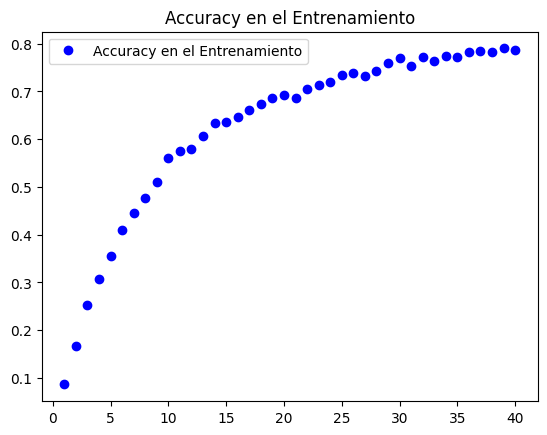

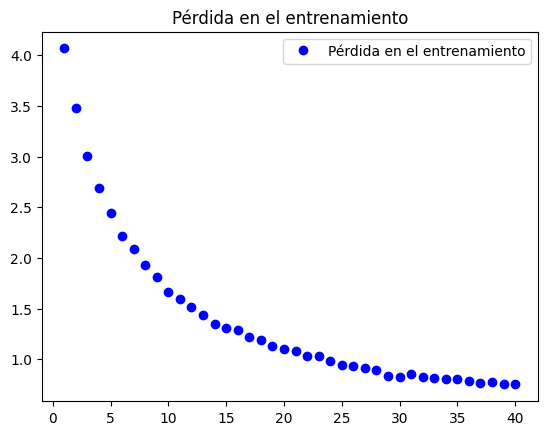

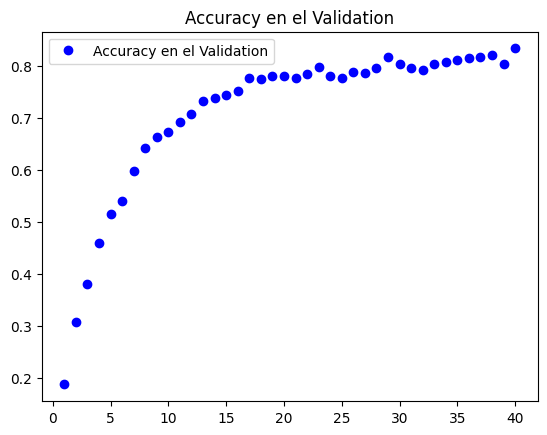

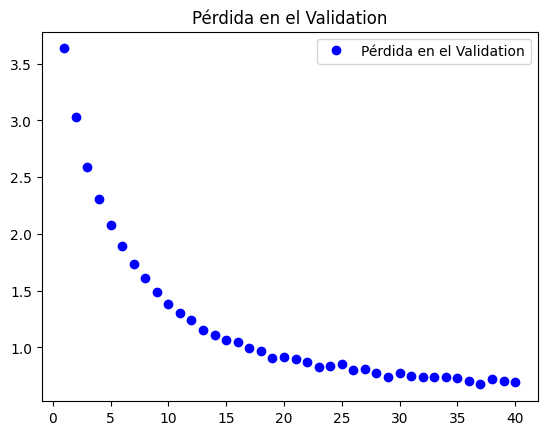

In [46]:
acc = history.history['acc'] + history2.history['acc'] + history_ft.history['acc']
loss = history.history['loss'] + history2.history['loss'] + history_ft.history['loss']
val = history.history['val_acc'] + history2.history['val_acc'] + history_ft.history['val_acc']
val_loss = history.history['val_loss'] + history2.history['val_loss'] + history_fr.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='Accuracy en el Entrenamiento')
plt.title('Accuracy en el Entrenamiento')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='Pérdida en el entrenamiento')
plt.title('Pérdida en el entrenamiento')
plt.legend()

plt.show()

plt.plot(epochs,val,'bo',label='Accuracy en el Validation')
plt.title('Accuracy en el Validation')
plt.legend()

plt.figure()

plt.plot(epochs,val_loss, 'bo', label ='Pérdida en el Validation')
plt.title('Pérdida en el Validation')
plt.legend()

plt.show()

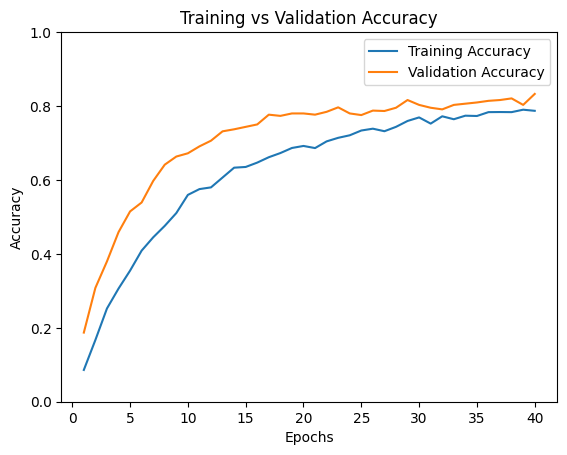

In [54]:
plt.figure()

plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val, label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.ylim(0, 1)

plt.show()

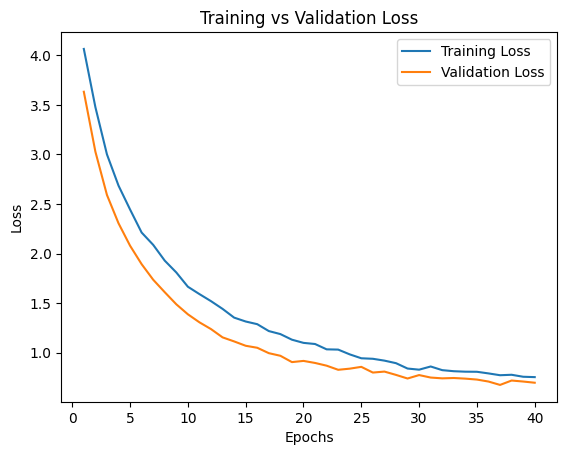

In [48]:
plt.figure()

plt.plot(epochs, loss, label='Training Loss')

plt.plot(epochs, val_loss, label='Validation Loss')

plt.title('Training vs Validation Loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend()

plt.show()

### Evaluación del modelo
Ahora, evaluaremos el modelo entrenado utilizando el conjunto de datos de prueba (`test_generator`) para determinar su rendimiento en datos no vistos.

In [49]:
test_loss, test_acc = loaded_model.evaluate(test_generator)
print(f'Test accuracy: {test_acc}')
print(f'Test loss: {test_loss}')

244/244 ━━━━━━━━━━━━━━━━━━━━ 99s 406ms/step - acc: 0.8021 - loss: 0.7390
Test accuracy: 0.802051305770874
Test loss: 0.7389940023422241


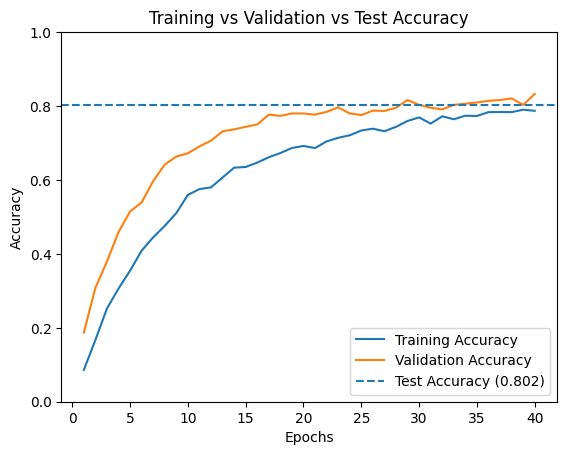

In [55]:
plt.figure()

plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val, label='Validation Accuracy')

plt.axhline(

    y=test_acc,
    linestyle='--',
    label=f'Test Accuracy ({test_acc:.3f})'

)

plt.title('Training vs Validation vs Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.ylim(0, 1)

plt.show()

### Matriz de Confusión
Ahora, generaremos una matriz de confusión para visualizar el rendimiento del modelo en cada clase. Esto nos permitirá identificar qué clases el modelo clasifica correctamente y cuáles confunde.

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = loaded_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)


244/244 ━━━━━━━━━━━━━━━━━━━━ 115s 468ms/step


In [52]:
true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

### Matrices de Confusión Divididas
Para una mejor visualización, dividiremos la matriz de confusión completa en sub-matrices, mostrando 15 clases en cada una.

<Figure size 1500x1500 with 0 Axes>

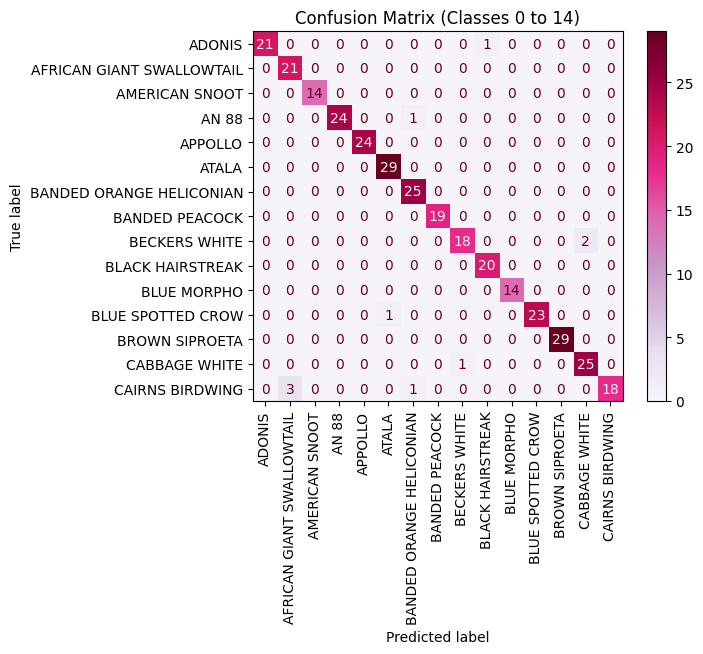

<Figure size 1500x1500 with 0 Axes>

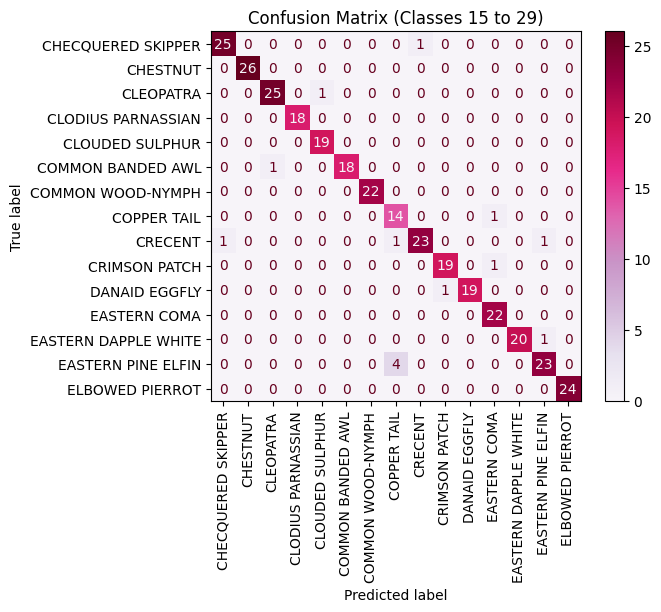

<Figure size 1500x1500 with 0 Axes>

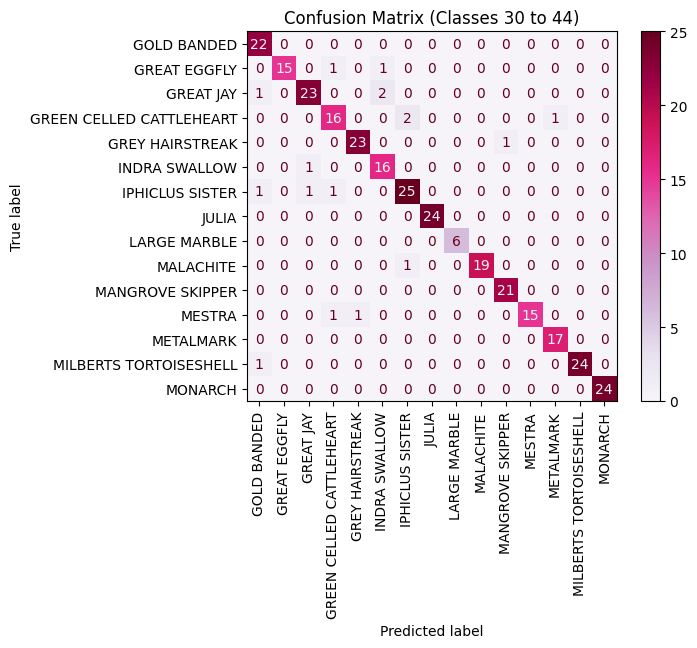

<Figure size 1500x1500 with 0 Axes>

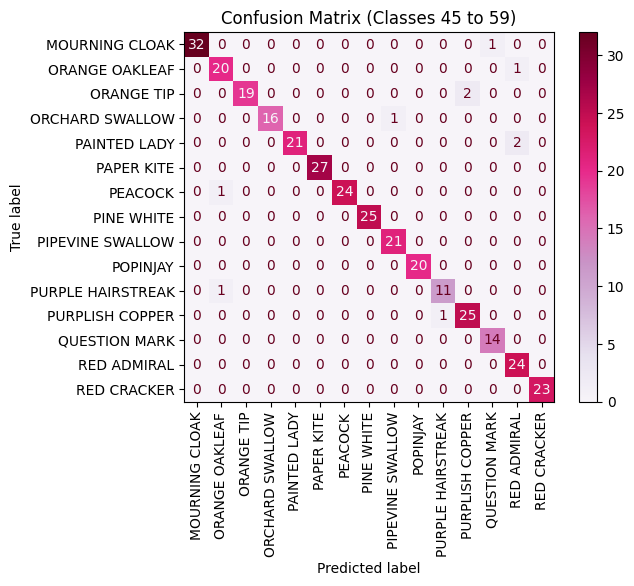

<Figure size 1500x1500 with 0 Axes>

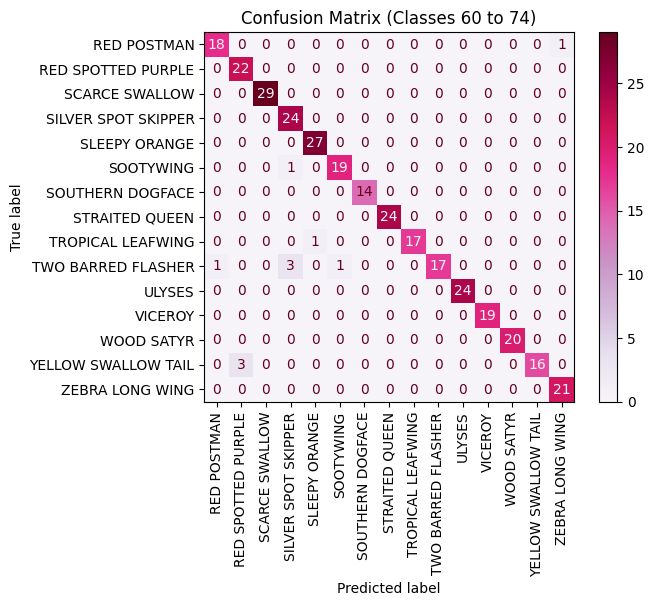

In [53]:
classes_per_matrix = 15

num_sub_matrices = (len(class_labels) + classes_per_matrix - 1) // classes_per_matrix

for i in range(num_sub_matrices):
    start_index = i * classes_per_matrix
    end_index = min((i + 1) * classes_per_matrix, len(class_labels))

    sub_class_labels = class_labels[start_index:end_index]

    sub_cm = cm[start_index:end_index, start_index:end_index]

    plt.figure(figsize=(15, 15))
    disp = ConfusionMatrixDisplay(confusion_matrix=sub_cm, display_labels=sub_class_labels)
    disp.plot(cmap=plt.cm.PuRd, xticks_rotation='vertical')
    plt.title(f'Confusion Matrix (Classes {start_index} to {end_index-1})')
    plt.show()